# Package

In [80]:
from ISLP import load_data
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from ISLP.models import summarize 

# Load

In [5]:
Weekly = load_data("Weekly")

In [9]:
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


# a) Numerical and graphical summaries

## How many of variable and obervation the dataframe contain? 

In [7]:
Weekly.shape

(1089, 9)

There are 1089 obrvation and 9 variable

## What are the variable

In [8]:
Weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

The dataframe contain the variable to decribe trading :
- year : year of the operation
- Lag1...5 : The Yield of lat day, the day after that and o on.
- Today : the Yield of today
- Direction : The direction of the Yield if it increae "Up" or not "Down" 

## I Direction the labelization of Today Yield? 

In [13]:
# Contitute the dataframe of two variable
Weekly_today_direction = Weekly[["Today", "Direction"]]
Weekly_today_direction.head()

,Today,Direction
0,-0.270,Down
1,-2.576,Down
2,3.514,Up
3,0.712,Up
4,1.178,Up


In [17]:
Weekly_today_direction.dtypes

Today         float64
Direction    category
dtype: object

In [32]:
# Verify if we have potive number for all Up
mask = Weekly_today_direction["Today"] >= 0
bool = Weekly_today_direction.loc[mask, "Direction"] == 'Up'
bool.value_counts()

Direction
True    605
Name: count, dtype: int64

As we can see, the label ‘Up’ is assigned to the positive yield as of today.

# Have we cla imbalance of Direction? 

In [33]:
Weekly_today_direction["Direction"].value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

The number of Up label i ignificantely different from Down. Cla imbalance i real. 

# What lag may explain more the Today Yield? 

array([[<Axes: title={'center': 'Lag1'}, xlabel='Direction'>,
        <Axes: title={'center': 'Lag2'}, xlabel='Direction'>],
       [<Axes: title={'center': 'Lag3'}, xlabel='Direction'>,
        <Axes: title={'center': 'Lag4'}, xlabel='Direction'>],
       [<Axes: title={'center': 'Lag5'}, xlabel='Direction'>, <Axes: >]],
      dtype=object)

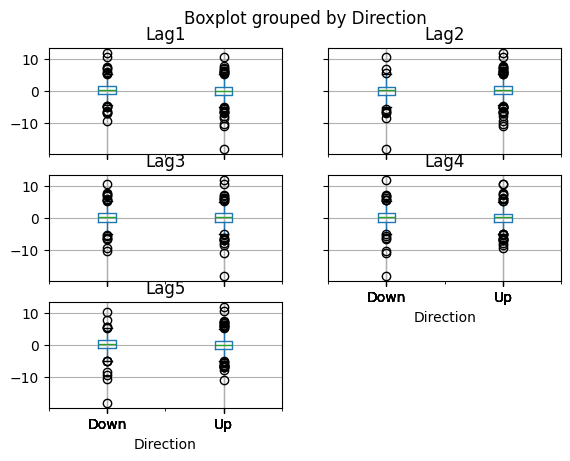

In [39]:
Weekly.boxplot(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'], by='Direction')

Thi chart can't realy how the correlation between Yeild of today and lat day Yiel. Let' ue the correlation

In [ ]:
weekly_numeric = Weekly.drop(["Year", "Direction"], axis= 1)
weekly_numeric

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
0,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270
1,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576
2,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514
3,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712
4,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178
...,...,...,...,...,...,...,...
1084,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969
1085,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281
1086,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283
1087,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034


            Lag1      Lag2      Lag3      Lag4      Lag5    Volume     Today
Lag1    1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951 -0.075032
Lag2   -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513  0.059167
Lag3    0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288 -0.071244
Lag4   -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075 -0.007826
Lag5   -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517  0.011013
Volume -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000 -0.033078
Today  -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078  1.000000 Axes(0.125,0.11;0.62x0.77)


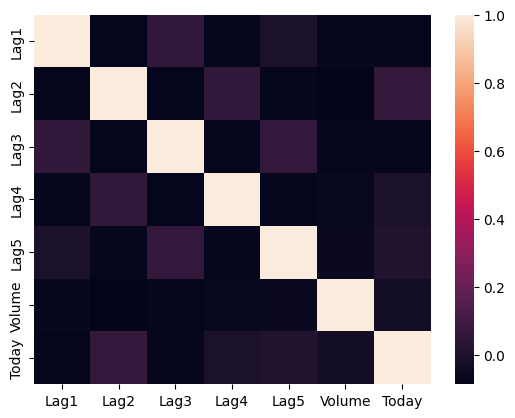

In [50]:
corr_matrix = weekly_numeric.corr()

print(corr_matrix, sns.heatmap(corr_matrix))

The correlation is not relevant. They are less than 0.1. 

# I relationhip not linear? 

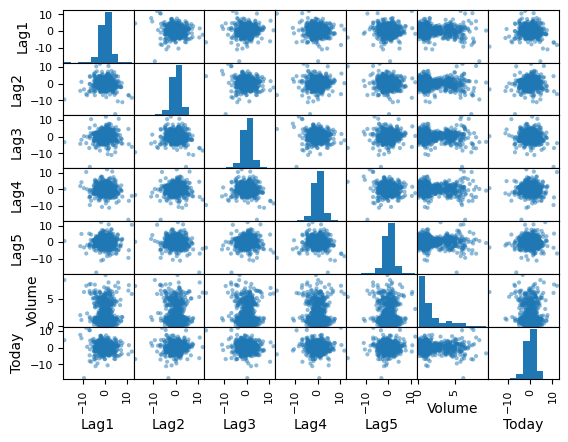

In [54]:
pd.plotting.scatter_matrix(weekly_numeric)
plt.show()

We have relashionphi but clearly, it is not linear. 

# b) Logistic regression

In [63]:
import statsmodels.api as sm

In [64]:
# Dataframe
Weekly_without_today = Weekly.drop("Today", axis=1)

In [88]:
# Contitue the feature and target
X = Weekly_today_direction.drop("Direction", axis=1).copy()
Y = Weekly_today_direction["Direction"].copy()
Y = Weekly_today_direction["Direction"] == "Up"

In [91]:
# Launch Logistic Regression
model_logistic_regression = sm.GLM(
    Y, X, family= sm.families.Binomial()
).fit()
model_logistic_regression
model_logistic_regression.summary()

c:\Users\Mita\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\Mita\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\Mita\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1088
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Wed, 18 Feb 2026   Deviance:                   7.3444e-08
Time:                        12:47:23   Pearson chi2:                 3.67e-08
No. Iterations:                    41   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Today       8559.9416   8.13e+05      0.011      0.992   -1.59e+06     1.6e+06
==============================================================================
"""